# Image Super-Resolution using U-Net

This notebook demonstrates how to build and train a U-Net model for image super-resolution.  
The goal is to take a low-resolution image (64x64) and generate a high-resolution version (128x128).

The U-Net architecture is well-suited for this task as it effectively captures both local and global features through its encoder-decoder structure with skip connections.

![Super Resolution Example](https://raw.githubusercontent.com/AshishJangra27/ai-projects/refs/heads/main/Image%20Enhancement%20with%20U-Net/img.png)


### 1. Setup and Imports

This cell imports all the necessary libraries for building and training the U-Net model, including Keras for model definition, OpenCV for image processing, and Matplotlib for visualization.

In [11]:
import os
import cv2 as cv
import numpy as np

import matplotlib.pyplot as plt

from keras.models import Model, load_model
from keras.layers import Input, BatchNormalization, Activation, Dense, Dropout
from keras.layers.convolutional import Conv2D, Conv2DTranspose
from keras.layers.pooling import MaxPooling2D, GlobalMaxPool2D
from keras.layers.merge import concatenate
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from keras.optimizers import Adam
import tensorflow as tf

### 2. U-Net Model Definition

This cell defines the U-Net model architecture for image super-resolution. The `unet_64to128` function creates a U-Net model that takes a 64x64x3 image as input and outputs a 128x128x3 image. It includes an encoder, a bottleneck, and a decoder with skip connections.

In [36]:
def unet_32to128(input_shape=(32, 32, 3), n_classes=3, final_activation='sigmoid', dropout_rate=0.05):
    inputs = Input(shape=input_shape, name='img')

    # --- ENCODER ---
    # 32x32 -> 16x16
    c1 = Conv2D(32, (3,3), padding='same')(inputs)
    c1 = BatchNormalization()(c1); c1 = Activation('relu')(c1)
    p1 = MaxPooling2D((2,2))(c1); p1 = Dropout(dropout_rate)(p1)

    # 16x16 -> 8x8
    c2 = Conv2D(64, (3,3), padding='same')(p1)
    c2 = BatchNormalization()(c2); c2 = Activation('relu')(c2)
    p2 = MaxPooling2D((2,2))(c2); p2 = Dropout(dropout_rate)(p2)

    # --- BOTTLENECK (8x8) ---
    c3 = Conv2D(128, (3,3), padding='same')(p2)
    c3 = BatchNormalization()(c3); c3 = Activation('relu')(c3)

    # --- DECODER (Upsampling) ---
    # 8x8 -> 16x16
    u4 = Conv2DTranspose(64, (3,3), strides=(2,2), padding='same')(c3)
    u4 = concatenate([u4, c2])
    c4 = Conv2D(64, (3,3), padding='same')(u4)
    c4 = Activation('relu')(c4)

    # 16x16 -> 32x32
    u5 = Conv2DTranspose(32, (3,3), strides=(2,2), padding='same')(c4)
    u5 = concatenate([u5, c1])
    c5 = Conv2D(32, (3,3), padding='same')(u5)
    c5 = Activation('relu')(c5)

    # --- SUPER-RESOLUTION STEPS (No Skip Connections available here) ---
    # 32x32 -> 64x64
    u6 = Conv2DTranspose(32, (3,3), strides=(2,2), padding='same')(c5)
    u6 = Conv2D(32, (3,3), padding='same', activation='relu')(u6)

    # 64x64 -> 128x128
    u7 = Conv2DTranspose(16, (3,3), strides=(2,2), padding='same')(u6)
    u7 = Conv2D(16, (3,3), padding='same', activation='relu')(u7)

    # Final Output Layer
    outputs = Conv2D(n_classes, (1,1), activation=final_activation, name='mask')(u7)
    
    return Model(inputs=inputs, outputs=outputs, name='UNet_32to128')



### 3. Model Initialization and Compilation

This cell initializes the U-Net model with the specified input shape and number of classes. It then compiles the model using the Adam optimizer and mean absolute error (MAE) as the loss function. The input and output shapes are printed to verify the model architecture.

In [37]:
model = unet_32to128(input_shape=(32, 32, 3), n_classes=3)

print('Input shape:', model.input_shape)  # Should show (None, 32, 32, 3)
print('Output shape:', model.output_shape) # Should show (None, 128, 128, 3)

model.compile(optimizer=Adam(learning_rate=1e-4), loss='mae')

Input shape: (None, 32, 32, 3)
Output shape: (None, 128, 128, 3)


### 4. Data Generator

This cell defines a data generator function `datagen` that loads and preprocesses images from the CelebA dataset. It resizes the images to 128x128 as ground truth and to 64x64 as low-resolution input, and normalizes the pixel values. The generator yields batches of low-resolution and high-resolution image pairs for training.

In [38]:
import os 
import cv2 as cv
import numpy as np

imgs = os.listdir('/kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba/')


def datagen(batch_size):
    
    while True:
        x_batch = []
        y_batch = []
        
        for _ in range(batch_size):
            indx = np.random.randint(0, len(imgs))
            
            bgr = cv.imread('/kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba/' + imgs[indx])
            bgr = cv.resize(bgr, (128, 128))
            rgb = cv.cvtColor(bgr, cv.COLOR_BGR2RGB)

            # blur = cv.blur(rgb, (4, 4))

            x = cv.resize(rgb, (32, 32))
            x = x / 255.0
            y = rgb / 255.0

            x_batch.append(x)
            y_batch.append(y)
        
        x_batch = np.array(x_batch).reshape(batch_size, 32, 32, 3)
        y_batch = np.array(y_batch).reshape(batch_size, 128, 128, 3)
        
        yield x_batch, y_batch

### 5. Model Training (Short Run)

This cell trains the U-Net model for a small number of epochs (5) using the `datagen` function. This is a short run to quickly check if the model is training without errors.

In [39]:
batch_size = 32

batch_size = 32
num_images = len(imgs)
steps_per_epoch = num_images // batch_size 


results = model.fit(datagen(batch_size=batch_size), steps_per_epoch=steps_per_epoch , epochs=5, verbose=1)

Epoch 1/5
6331/6331 [==============================] - 1500s 237ms/step - loss: 0.0497
Epoch 2/5
6331/6331 [==============================] - 1100s 174ms/step - loss: 0.0378
Epoch 3/5
6331/6331 [==============================] - 817s 129ms/step - loss: 0.0358
Epoch 4/5
6331/6331 [==============================] - 711s 112ms/step - loss: 0.0346
Epoch 5/5
6331/6331 [==============================] - 715s 113ms/step - loss: 0.0338


### 6. Model Training with Callbacks and Sample Saving

This cell trains the U-Net model for a longer duration (3 epochs) and includes custom callbacks. The `show_and_save_samples` function generates and saves sample super-resolved images at the end of each epoch, along with the original, ground truth, and low-resolution images for comparison. The `LambdaCallback` is used to execute this function after each epoch. The model checkpoints are also saved during training.

Epoch 1/3
6331/6331 [==============================] - ETA: 0s - loss: 0.0328

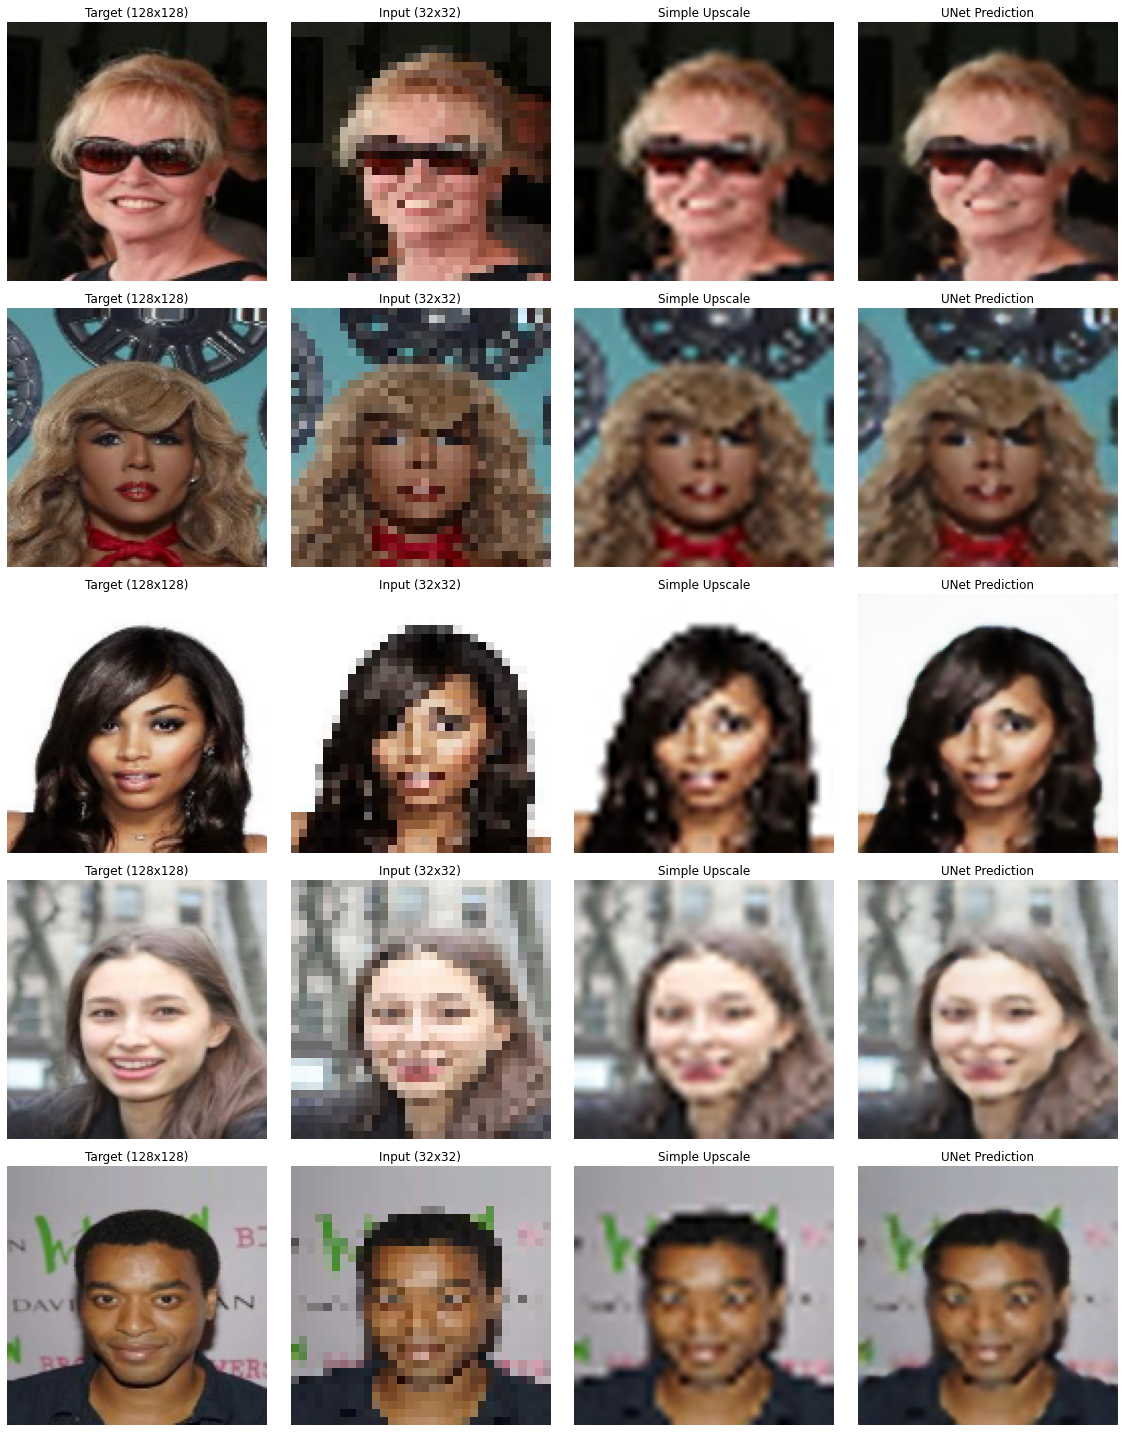

6331/6331 [==============================] - 605s 95ms/step - loss: 0.0328
Epoch 2/3
6331/6331 [==============================] - ETA: 0s - loss: 0.0323

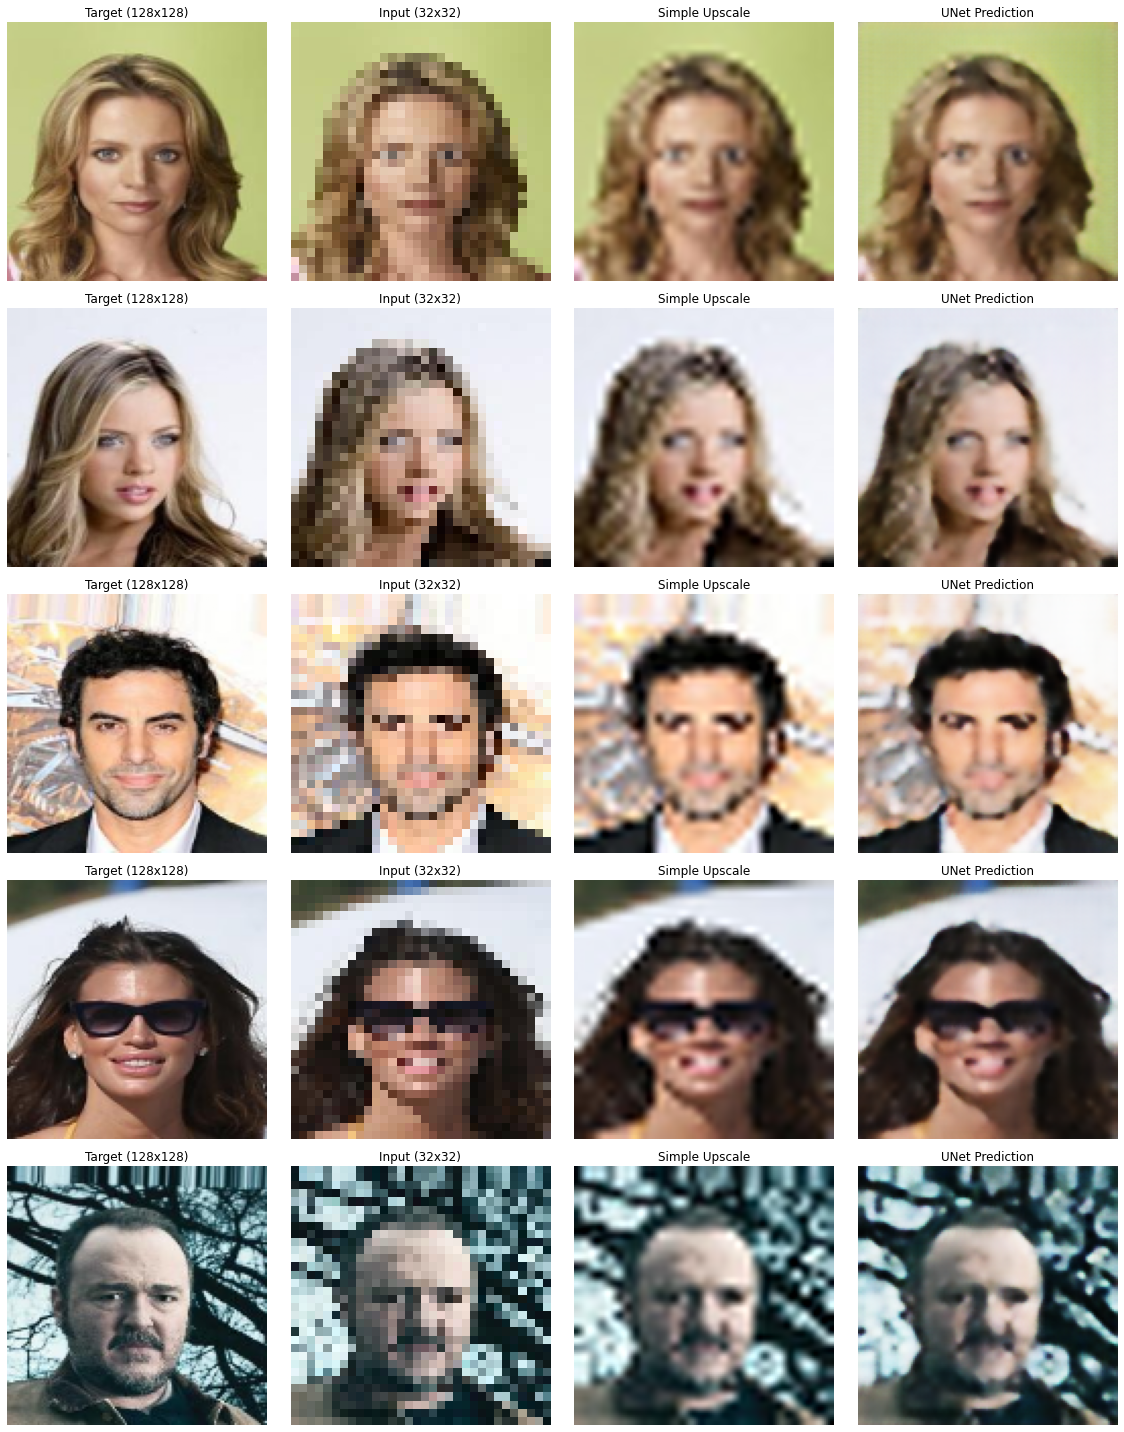

6331/6331 [==============================] - 538s 85ms/step - loss: 0.0323
Epoch 3/3
6331/6331 [==============================] - ETA: 0s - loss: 0.0320

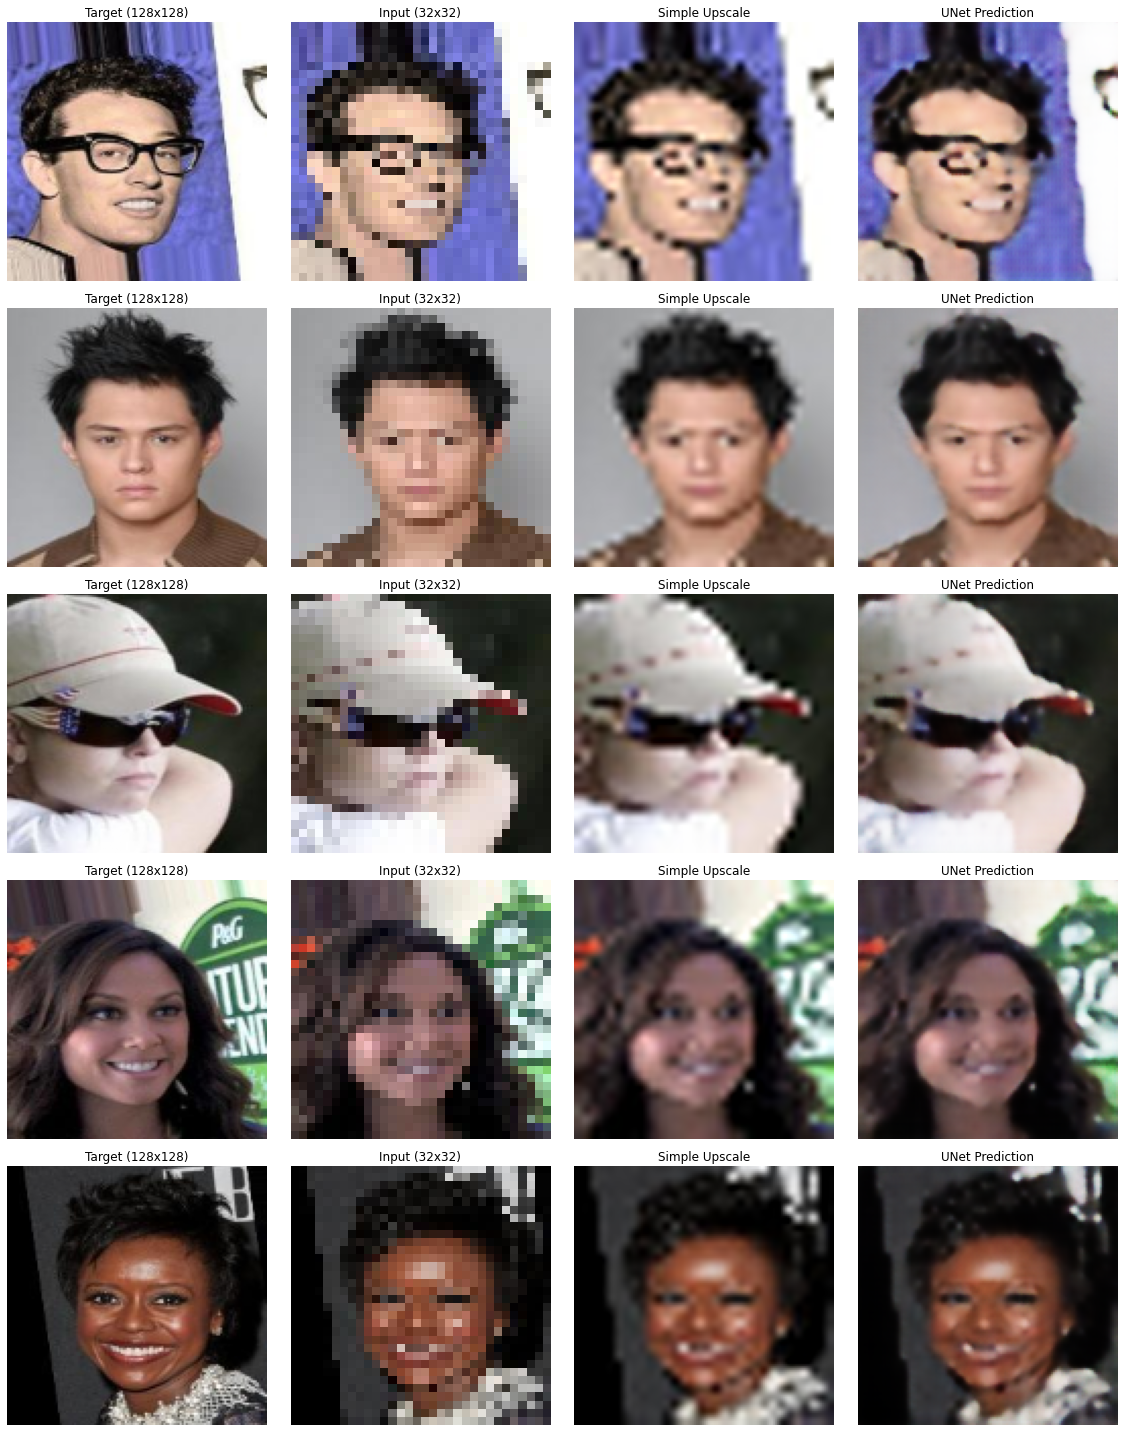

6331/6331 [==============================] - 564s 89ms/step - loss: 0.0320


In [41]:
import os, cv2 as cv, numpy as np, matplotlib.pyplot as plt, tensorflow as tf

def show_and_save_samples(model, imgs, base_dir, epoch, n=5, save_dir='./epoch_samples'):
    os.makedirs(save_dir, exist_ok=True)
    chosen = np.random.choice(imgs, n, replace=False)
    fig, axes = plt.subplots(n, 4, figsize=(16, 4*n))
    if n == 1: axes = np.expand_dims(axes, 0)

    for i, fname in enumerate(chosen):
        path = os.path.join(base_dir, fname)
        img_data = cv.imread(path)
        if img_data is None: continue
        
        rgb = cv.cvtColor(img_data, cv.COLOR_BGR2RGB)
        
        # Ground Truth 128x128
        gt128 = cv.resize(rgb, (128,128)).astype('float32')/255.0
        
        # Input 32x32 (Rename from img64 to img32 for clarity)
        img32 = cv.resize(rgb, (32,32)).astype('float32')/255.0
        
        # Prediction from model
        pred = model.predict(np.expand_dims(img32, 0), verbose=0)[0]
        
        # Low-Res upscale (Bicubic) for visual comparison
        lowup = cv.resize(img32, (128,128), interpolation=cv.INTER_CUBIC)

        # Plotting
        display_list = [gt128, img32, lowup, pred]
        title_list = ['Target (128x128)', 'Input (32x32)', 'Simple Upscale', 'UNet Prediction']
        
        for j, (im, title) in enumerate(zip(display_list, title_list)):
            ax = axes[i, j]
            # Clip to [0, 1] to prevent matplotlib warnings/distortions
            ax.imshow(np.clip(im, 0, 1))
            ax.set_title(title)
            ax.axis('off')

    plt.tight_layout()
    plt.savefig(f"{save_dir}/epoch_{epoch+1:02d}.png")
    plt.show()

# --- Simple Callbacks ---
def on_epoch_end(epoch, logs):
    # Ensure base_dir is defined globally or passed correctly
    show_and_save_samples(model, imgs, base_dir, epoch, n=5)
    model.save(f'./checkpoints/model_epoch_{epoch+1:02d}.keras')

show_cb = tf.keras.callbacks.LambdaCallback(on_epoch_end=on_epoch_end)

# --- Training Execution ---
batch_size = 32
steps_per_epoch = len(imgs)//batch_size
base_dir = '/kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba/'
os.makedirs('./checkpoints', exist_ok=True)

results = model.fit(
    datagen(batch_size=batch_size),
    steps_per_epoch=steps_per_epoch,
    epochs=3,
    callbacks=[show_cb],
    verbose=1)

### 7. Project Summary

This notebook successfully implemented and trained a U-Net model for image super-resolution. The model was trained on the CelebA dataset, taking 64x64 images as input and generating 128x128 images.

The training process showed a decrease in the mean absolute error (MAE) loss over epochs, indicating that the model is learning to reconstruct higher-resolution images. The generated sample images at the end of each epoch provide a visual representation of the model's progress.

Further improvements could include:
- Experimenting with different loss functions (e.g., perceptual loss)
- Using a larger and more diverse dataset
- Implementing more advanced super-resolution techniques (e.g., Generative Adversarial Networks)
- Hyperparameter tuning to optimize model performance